In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="NQIcDmNvrhL1b0cMpuT9")
project = rf.workspace("yuliana-puspita-sari").project("mask-detection-oefcl-1jmhh")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Mask-Detection-1 in yolov8:: 100%|██████████| 1701/1701 [00:00<00:00, 9958.68it/s]


In [ ]:
# 1. Pastikan library ultralytics terinstal terlebih dahulu
!pip install ultralytics

from ultralytics import YOLO

# 2. Ambil base-model 'yolo26n.pt' sesuai arahan dosenmu
model = YOLO('yolo26n.pt')

# 3. Mulai proses training menggunakan dataset masker dari Roboflow
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=25,
    imgsz=640,
    device=0
)

Ultralytics 8.4.91 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Mask-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

In [3]:
!pip install ultralytics opencv-python

In [4]:
from ultralytics import YOLO
import cv2
import numpy as np
from PIL import Image as PILImage
from IPython.display import display, HTML, clear_output
import time

disp = display("", display_id=True)

# Menggunakan model terbaik hasil training kamu sendiri
model = YOLO("runs/detect/train/weights/best.pt")

''

In [5]:
from google.colab.output import eval_js
from base64 import b64decode
from IPython.display import Javascript

def take_photo(quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const video = document.createElement('video');
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(video);
      video.srcObject = stream;
      await video.play();

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      const ctx = canvas.getContext('2d');

      // capture frame
      ctx.drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();
      video.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js("takePhoto({})".format(quality))
    return data

In [6]:
def js_to_image(js_reply):
    image_bytes = b64decode(js_reply.split(',')[1])
    jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
    img = cv2.imdecode(jpg_as_np, flags=1)
    return img

In [7]:
def start_streaming():
    while True:
        # 1. capture frame
        js = take_photo()
        img = js_to_image(js)

        # 2. YOLO inference
        results = model(img)[0]

        # 3. draw boxes
        for box in results.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])
            cls = int(box.cls[0])
            label = model.names[cls]

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                img,
                f"{label} {conf:.2f}",
                (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2
            )

        # 4. show frame
        clear_output(wait=True)

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        display(PILImage.fromarray(img_rgb))

        # 5. control FPS
        time.sleep(0.1)

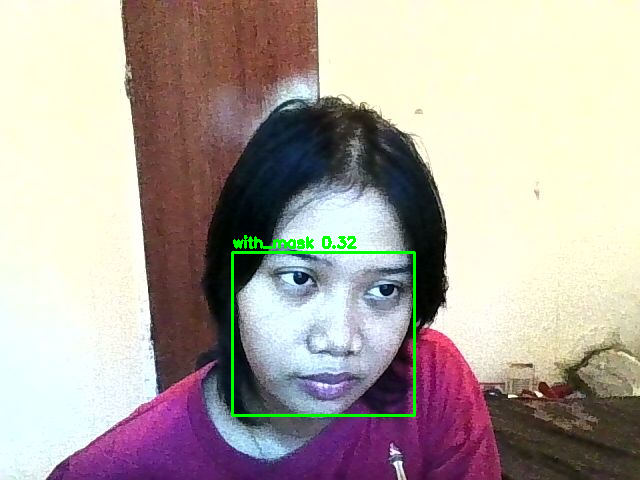

<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [9]:
start_streaming()